In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/anemia_detection/datasets')

['palpablepalm_dataset.zip',
 'fingernails_dataset.zip',
 'conjunctiva_dataset.zip']

In [ ]:
!unzip "/content/drive/MyDrive/anemia_detection/datasets/palpablepalm_dataset.zip"

!unrar x "/content/Anemia Detection using Palpable Palm Image Datasets from Ghana/Palm.rar"

Archive:  /content/drive/MyDrive/anemia_detection/datasets/palpablepalm_dataset.zip
  inflating: Anemia Detection using Palpable Palm Image Datasets from Ghana/Palm.rar  

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Anemia Detection using Palpable Palm Image Datasets from Ghana/Palm.rar

Creating    Palm                                                      OK
Extracting  Palm/Anemic-260 (10).png                                       0%  OK 
Extracting  Palm/Anemic-260 (11).png                                       0%  OK 
Extracting  Palm/Anemic-260 (12).png                                       0%  OK 
Extracting  Palm/Anemic-260 (2).png                                        0%  OK 
Extracting  Palm/Anemic-260 (3).png                                        0%  OK 
Extracting  Palm/Anemic-260 (4).png                                        0%  OK 
Extracting  Palm/Anemic-260 (5

In [ ]:
!unzip "/content/drive/MyDrive/anemia_detection/datasets/conjunctiva_dataset.zip"

Archive:  /content/drive/MyDrive/anemia_detection/datasets/conjunctiva_dataset.zip
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (6).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (2).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (3).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (4).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (5).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (7).png  
  inflating: Application of Machine Learn

In [ ]:
!unzip "/content/drive/MyDrive/anemia_detection/datasets/fingernails_dataset.zip"

!unrar x "/content/Detection of Anemia using Colour of the Fingernails Image Datasets from Ghana/Fingernails.rar"

Archive:  /content/drive/MyDrive/anemia_detection/datasets/fingernails_dataset.zip
  inflating: Detection of Anemia using Colour of the Fingernails Image Datasets from Ghana/Fingernails.rar  

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Detection of Anemia using Colour of the Fingernails Image Datasets from Ghana/Fingernails.rar

Creating    Fingernails                                               OK
Extracting  Fingernails/Anemic-Fin-007 (10).png                            0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (11).png                            0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (12).png                            0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (2).png                             0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (3).png                             0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (4).png                             

In [ ]:
import os
import re
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

def extract_patient_key(path):
    filename = os.path.basename(path)
    name = os.path.splitext(filename)[0]

    # augmentation suffixlerini temizle: (2), (3), ..., (12)
    name = re.sub(r"\s*\(\d+\)$", "", name)

    # yazım hatasını düzelt
    name_lower = name.lower().replace("anrmic", "anemic")

    # sınıf bilgisi
    if name_lower.startswith("non"):
        label_text = "Non-Anemic"
        label = 0
    else:
        label_text = "Anemic"
        label = 1

    # dosya adındaki 3 haneli sayıyı al
    # örn: Anemic-001, Anemic-FN-001, Non-AnemicP-204
    nums = re.findall(r"(\d{3})", name_lower)

    if len(nums) == 0:
        return None, None, None

    patient_no = nums[-1]

    # RA, FV gibi varyantları kişi ID'ye dahil etmiyoruz
    patient_key = f"{label_text}_{patient_no}"

    return patient_key, label, label_text

In [ ]:
import os
import glob
import pandas as pd

palm_paths = glob.glob(os.path.join("/content/Palm", "**", "*.png"), recursive=True)
nail_paths = glob.glob(os.path.join("/content/Fingernails", "**", "*.png"), recursive=True)
conj_paths = glob.glob(os.path.join(
    "/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana",
    "**",
    "*.png"
), recursive=True)


def build_dataframe(image_paths, modality):
    rows = []

    for path in image_paths:
        patient_key, label, label_text = extract_patient_key(path)

        if patient_key is None:
            continue

        rows.append({
            "path": path,
            "patient_key": patient_key,
            "label": label,
            "class": label_text,
            "modality": modality
        })

    return pd.DataFrame(rows)

df_palm = build_dataframe(palm_paths, "palm")
df_nail = build_dataframe(nail_paths, "nail")
df_conj = build_dataframe(conj_paths, "conjunctiva")

In [ ]:
palm_ids = set(df_palm["patient_key"])
nail_ids = set(df_nail["patient_key"])
conj_ids = set(df_conj["patient_key"])

common_ids = palm_ids & nail_ids & conj_ids

print("Palm kişi sayısı:", len(palm_ids))
print("Nail kişi sayısı:", len(nail_ids))
print("Conjunctiva kişi sayısı:", len(conj_ids))
print("Üç veri setinde ortak kişi sayısı:", len(common_ids))

Palm kişi sayısı: 475
Nail kişi sayısı: 476
Conjunctiva kişi sayısı: 455
Üç veri setinde ortak kişi sayısı: 454


In [ ]:
df_palm_common = df_palm[df_palm["patient_key"].isin(common_ids)].copy()
df_nail_common = df_nail[df_nail["patient_key"].isin(common_ids)].copy()
df_conj_common = df_conj[df_conj["patient_key"].isin(common_ids)].copy()

In [ ]:
common_df = pd.DataFrame({
    "patient_key": sorted(list(common_ids))
})

common_df["label"] = common_df["patient_key"].apply(
    lambda x: 1 if x.startswith("Anemic") else 0
)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        common_df,
        common_df["label"],
        groups=common_df["patient_key"]
    )
)

train_ids = set(common_df.iloc[train_idx]["patient_key"])
test_ids = set(common_df.iloc[test_idx]["patient_key"])

print("Train kişi sayısı:", len(train_ids))
print("Test kişi sayısı:", len(test_ids))
print("Train sınıf dağılımı:")
print(common_df.iloc[train_idx]["label"].value_counts())
print("Test sınıf dağılımı:")
print(common_df.iloc[test_idx]["label"].value_counts())

Train kişi sayısı: 363
Test kişi sayısı: 91
Train sınıf dağılımı:
label
1    199
0    164
Name: count, dtype: int64
Test sınıf dağılımı:
label
1    51
0    40
Name: count, dtype: int64


In [ ]:
palm_train = df_palm_common[df_palm_common["patient_key"].isin(train_ids)]
palm_test  = df_palm_common[df_palm_common["patient_key"].isin(test_ids)]

nail_train = df_nail_common[df_nail_common["patient_key"].isin(train_ids)]
nail_test  = df_nail_common[df_nail_common["patient_key"].isin(test_ids)]

conj_train = df_conj_common[df_conj_common["patient_key"].isin(train_ids)]
conj_test  = df_conj_common[df_conj_common["patient_key"].isin(test_ids)]

In [ ]:
# =========================
# FEATURE EXTRACTION FUNCTION
# =========================
import cv2
import numpy as np

def extract_features_from_df(df_exp):
    groups = []
    features = []
    labels = []

    for _, row in df_exp.iterrows():
        img = cv2.imread(row["path"])
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        R = img[:, :, 0]
        G = img[:, :, 1]
        B = img[:, :, 2]

        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        H, S, V = cv2.split(hsv)

        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        L, a, b = cv2.split(lab)

        R_mean = np.mean(R)
        G_mean = np.mean(G)
        B_mean = np.mean(B)

        features.append([
            np.mean(R), np.std(R),
            np.mean(G), np.std(G),
            np.mean(B), np.std(B),

            np.mean(L), np.std(L),
            np.mean(a), np.std(a),
            np.mean(b), np.std(b),

            np.mean(H), np.std(H),
            np.mean(S), np.std(S),
            np.mean(V), np.std(V),

            np.percentile(R, 25), np.percentile(R, 50), np.percentile(R, 75),
            np.percentile(G, 25), np.percentile(G, 50), np.percentile(G, 75),
            np.percentile(B, 25), np.percentile(B, 50), np.percentile(B, 75),

            R_mean / (G_mean + 1e-6),
            R_mean / (B_mean + 1e-6),
            G_mean / (B_mean + 1e-6),

            R_mean / (R_mean + G_mean + B_mean + 1e-6),
            G_mean / (R_mean + G_mean + B_mean + 1e-6),
            B_mean / (R_mean + G_mean + B_mean + 1e-6),

            np.mean(gray),
            np.std(gray),
            np.var(gray)
        ])

        labels.append(1 if row["class"] == "Anemic" else 0)
        groups.append(row["patient_key"])

    X = np.array(features, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    groups = np.array(groups)

    return X, y, groups

In [ ]:
X_palm_train, y_palm_train, groups_palm_train = extract_features_from_df(palm_train)
X_palm_test,  y_palm_test,  groups_palm_test  = extract_features_from_df(palm_test)

X_nail_train, y_nail_train, groups_nail_train = extract_features_from_df(nail_train)
X_nail_test,  y_nail_test,  groups_nail_test  = extract_features_from_df(nail_test)

X_conj_train, y_conj_train, groups_conj_train = extract_features_from_df(conj_train)
X_conj_test,  y_conj_test,  groups_conj_test  = extract_features_from_df(conj_test)

In [ ]:
import numpy as np

def debug_dataset(name, X_train, y_train, X_test, y_test):
    print("\n====================")
    print(name)
    print("====================")

    # 1) Boş veri kontrolü
    print("Train size:", len(X_train))
    print("Test size:", len(X_test))

    # 2) Shape kontrolü
    if len(X_train) > 0:
        print("Train shape:", X_train.shape)
    if len(X_test) > 0:
        print("Test shape:", X_test.shape)

    # 3) NaN / inf kontrolü
    print("Train NaN:", np.isnan(X_train).sum())
    print("Train Inf:", np.isinf(X_train).sum())

    # 4) label dağılımı
    print("Train label dağılımı:", np.bincount(y_train) if len(y_train) > 0 else "EMPTY")
    print("Test label dağılımı:", np.bincount(y_test) if len(y_test) > 0 else "EMPTY")


# =========================
# ÇALIŞTIR
# =========================
debug_dataset("PALM", X_palm_train, y_palm_train, X_palm_test, y_palm_test)
debug_dataset("NAIL", X_nail_train, y_nail_train, X_nail_test, y_nail_test)
debug_dataset("CONJ", X_conj_train, y_conj_train, X_conj_test, y_conj_test)


PALM
Train size: 3247
Test size: 887
Train shape: (3247, 36)
Test shape: (887, 36)
Train NaN: 0
Train Inf: 0
Train label dağılımı: [1344 1903]
Test label dağılımı: [354 533]

NAIL
Train size: 3178
Test size: 954
Train shape: (3178, 36)
Test shape: (954, 36)
Train NaN: 0
Train Inf: 0
Train label dağılımı: [1320 1858]
Test label dağılımı: [375 579]

CONJ
Train size: 3325
Test size: 931
Train shape: (3325, 36)
Test shape: (931, 36)
Train NaN: 0
Train Inf: 0
Train label dağılımı: [1356 1969]
Test label dağılımı: [348 583]


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

base_palm = HistGradientBoostingClassifier(
 max_iter=100,
 learning_rate=0.5,
 max_depth=None,
 min_samples_leaf=1,
 max_leaf_nodes=31,
 random_state=42
)
palm_model = CalibratedClassifierCV(
 estimator=base_palm,
 method="isotonic",
 cv=5
)
base_nail = HistGradientBoostingClassifier(
 max_iter=100,
 learning_rate=0.5,
 max_depth=None,
 min_samples_leaf=20,
 max_leaf_nodes=31,
 l2_regularization=0.0,
 random_state=42
)
nail_model = CalibratedClassifierCV(
 estimator=base_nail,
 method="isotonic",
 cv=5
)
base_conj = XGBClassifier(
 n_estimators=1000,
 max_depth=3,
 subsample=1,
 colsample_bytree=0.95,
 reg_lambda=10,
 eval_metric="logloss",
 random_state=42
)
conj_model = CalibratedClassifierCV(
 estimator=base_conj,
 method="sigmoid",
 cv=5
)

In [ ]:
palm_model.fit(X_palm_train, y_palm_train)
nail_model.fit(X_nail_train, y_nail_train)
conj_model.fit(X_conj_train, y_conj_train)

CalibratedClassifierCV(cv=5,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.95,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=None, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=3,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=1000, n_jobs=None,
                                               num_parallel_tree=None, ...))

In [ ]:
#Test olasılıkları

palm_prob = palm_model.predict_proba(X_palm_test)[:, 1]
nail_prob = nail_model.predict_proba(X_nail_test)[:, 1]
conj_prob = conj_model.predict_proba(X_conj_test)[:, 1]

In [ ]:
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, f1_score
from sklearn.metrics import brier_score_loss

palm_pred = (palm_prob >= 0.5).astype(int)

print("PALM METRICS")
print("Brier:", brier_score_loss(y_palm_test, palm_prob))
print("LogLoss:", log_loss(y_palm_test, palm_prob))
print("AUC:", roc_auc_score(y_palm_test, palm_prob))
print("F1:", f1_score(y_palm_test, palm_pred))

nail_pred = (nail_prob >= 0.5).astype(int)

print("NAIL METRICS")
print("Brier:", brier_score_loss(y_nail_test, nail_prob))
print("LogLoss:", log_loss(y_nail_test, nail_prob))
print("AUC:", roc_auc_score(y_nail_test, nail_prob))
print("F1:", f1_score(y_nail_test, nail_pred))

conj_pred = (conj_prob >= 0.5).astype(int)

print("CONJ METRICS")
print("Brier:", brier_score_loss(y_conj_test, conj_prob))
print("LogLoss:", log_loss(y_conj_test, conj_prob))
print("AUC:", roc_auc_score(y_conj_test, conj_prob))
print("F1:", f1_score(y_conj_test, conj_pred))

PALM METRICS
Brier: 0.14689458019722737
LogLoss: 0.8898328648648834
AUC: 0.8612268260883392
F1: 0.8110687022900763
NAIL METRICS
Brier: 0.19102354731933302
LogLoss: 0.9963122489545211
AUC: 0.7918341968911917
F1: 0.7554019014693172
CONJ METRICS
Brier: 0.2616775647463206
LogLoss: 1.1327758845751712
AUC: 0.7847341337907375
F1: 0.7531305903398927


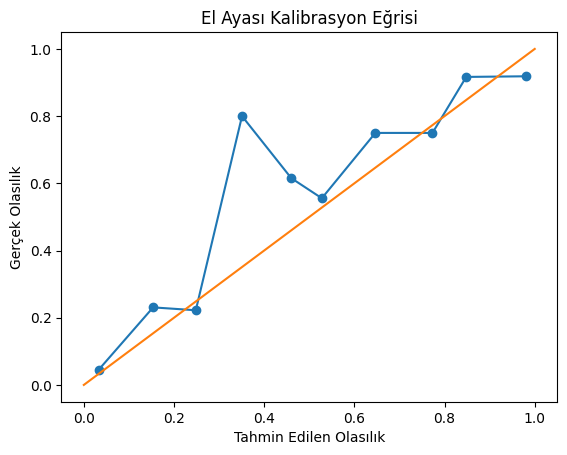

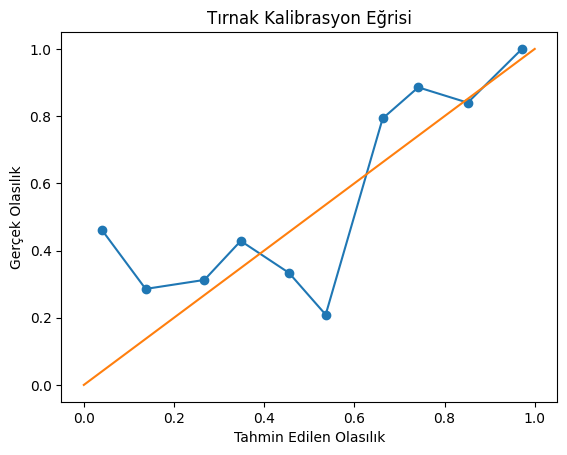

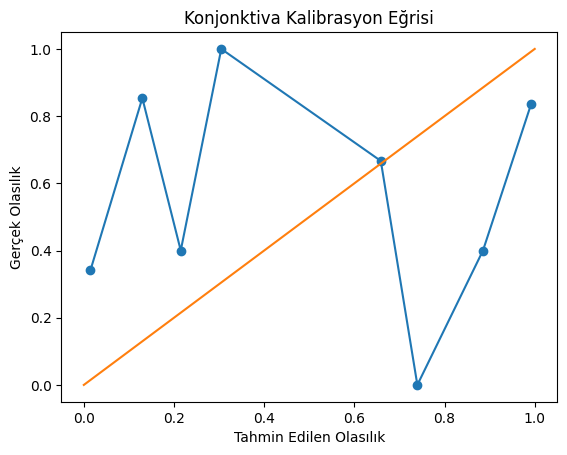

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_palm_test, palm_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1])
plt.title("El Ayası Kalibrasyon Eğrisi")
plt.xlabel("Tahmin Edilen Olasılık")
plt.ylabel("Gerçek Olasılık")
plt.show()


prob_true, prob_pred = calibration_curve(y_nail_test, nail_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1])
plt.title("Tırnak Kalibrasyon Eğrisi")
plt.xlabel("Tahmin Edilen Olasılık")
plt.ylabel("Gerçek Olasılık")
plt.show()


prob_true, prob_pred = calibration_curve(y_conj_test, conj_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1])
plt.title("Konjonktiva Kalibrasyon Eğrisi")
plt.xlabel("Tahmin Edilen Olasılık")
plt.ylabel("Gerçek Olasılık")
plt.show()

In [ ]:
def make_prob_df(test_df, probs, name):
    temp = test_df.copy()
    temp[name] = probs

    patient_prob = temp.groupby("patient_key").agg(
        y_true=("label", "first"),
        prob=(name, "mean")
    ).reset_index()

    patient_prob = patient_prob.rename(columns={"prob": name})

    return patient_prob

In [ ]:
palm_prob_df = make_prob_df(palm_test, palm_prob, "palm_prob")
nail_prob_df = make_prob_df(nail_test, nail_prob, "nail_prob")
conj_prob_df = make_prob_df(conj_test, conj_prob, "conj_prob")

In [ ]:
fusion_df = palm_prob_df.merge(
    nail_prob_df[["patient_key", "nail_prob"]],
    on="patient_key"
).merge(
    conj_prob_df[["patient_key", "conj_prob"]],
    on="patient_key"
)

In [ ]:
print(fusion_df.head())
print("Füzyon test kişi sayısı:", len(fusion_df))

  patient_key  y_true  palm_prob  nail_prob  conj_prob
0  Anemic_001       1   0.851760   0.791385   0.903290
1  Anemic_010       1   0.795742   0.877559   0.996498
2  Anemic_012       1   0.867978   0.929827   0.949510
3  Anemic_016       1   0.826799   0.533233   0.996981
4  Anemic_020       1   0.988121   0.722999   0.699895
Füzyon test kişi sayısı: 91


In [ ]:
import joblib
import os

save_path = "/content/drive/MyDrive/anemia_detection/saved_models/01062026"
os.makedirs(save_path, exist_ok=True)

joblib.dump(palm_model, os.path.join(save_path, "palm_model.pkl"))
joblib.dump(nail_model, os.path.join(save_path, "nail_model.pkl"))
joblib.dump(conj_model, os.path.join(save_path, "conj_model.pkl"))

['/content/drive/MyDrive/anemia_detection/saved_models/01062026/conj_model.pkl']

In [ ]:
fusion_df["final_prob"] = (
    0.45 * fusion_df["palm_prob"] +
    0.35 * fusion_df["nail_prob"] +
    0.20 * fusion_df["conj_prob"]
)

fusion_df["final_pred"] = (fusion_df["final_prob"] >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix

y_true = fusion_df["y_true"]
y_pred = fusion_df["final_pred"]
y_prob = fusion_df["final_prob"]

print("Fusion Accuracy:", accuracy_score(y_true, y_pred))
print("Fusion F1-score:", f1_score(y_true, y_pred))
print("Fusion AUC:", roc_auc_score(y_true, y_prob))
print("Fusion Precision:", precision_score(y_true, y_pred))
print("Fusion Recall:", recall_score(y_true, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Fusion Accuracy: 0.8461538461538461
Fusion F1-score: 0.8653846153846154
Fusion AUC: 0.9107843137254902
Fusion Precision: 0.8490566037735849
Fusion Recall: 0.8823529411764706
Confusion Matrix:
[[32  8]
 [ 6 45]]


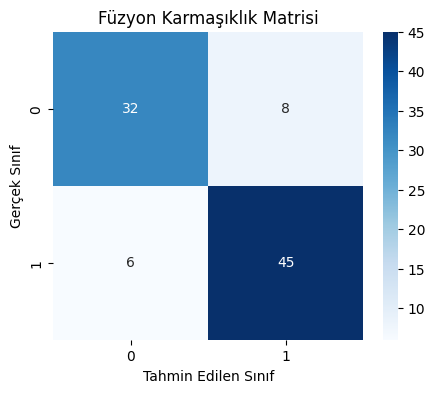

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Füzyon Karmaşıklık Matrisi")
plt.show()

In [ ]:
!pip install skl2onnx onnx onnxmltools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 11.4 MB/s eta 0:00:00


In [ ]:
!pip install skl2onnx onnxmltools onnx

import os
import numpy as np
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from onnxmltools import convert_xgboost

save_path = "/content/drive/MyDrive/anemia_detection/saved_models/onnx"
os.makedirs(save_path, exist_ok=True)

# =========================
# PALM
# =========================
initial_type = [("input", FloatTensorType([None, X_palm_train.shape[1]]))]

palm_onnx = convert_sklearn(
    palm_model.estimator,
    initial_types=initial_type,
    target_opset=12
)

with open(os.path.join(save_path, "palm_model.onnx"), "wb") as f:
    f.write(palm_onnx.SerializeToString())

# =========================
# NAIL
# =========================
initial_type = [("input", FloatTensorType([None, X_nail_train.shape[1]]))]

nail_onnx = convert_sklearn(
    nail_model.estimator,
    initial_types=initial_type,
    target_opset=12
)

with open(os.path.join(save_path, "nail_model.onnx"), "wb") as f:
    f.write(nail_onnx.SerializeToString())

# =========================
# CONJ (XGBoost)
# =========================
initial_type = [("input", FloatTensorType([None, X_conj_train.shape[1]]))]

conj_onnx = convert_xgboost(
    conj_model.estimator,
    initial_types=initial_type
)

with open(os.path.join(save_path, "conj_model.onnx"), "wb") as f:
    f.write(conj_onnx.SerializeToString())

print("ONNX export tamamlandı")

RuntimeError: No known ways to retrieve the number of classes for class <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>.